In [1]:
# 09/09

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

In [2]:
class SimpleModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleModel, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.activition = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activition(x)
        x = self.layer2(x)
        return x

In [3]:
input_size = 10
hidden_size = 20
output_size = 1
batch_size = 32
num_epochs = 5
learning_rate = 0.01
max_norm = 1.0

In [4]:
num_samples = 1000

X = torch.randn(num_samples, input_size)
y = torch.sum(X[:,:5], dim=1, keepdim=True) + torch.randn(num_samples, 1) * 0.1

In [5]:
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset,
                        batch_size=batch_size,
                        shuffle=True)
model = SimpleModel(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),
                      lr=learning_rate)

In [6]:
for epoch in range(num_epochs):
    total_loss = 0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(),
                            max_norm=max_norm)
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(epoch + 1, avg_loss)
print('학습완료')

with torch.no_grad():
    test_X = torch.randn(5, input_size)
    predictions = model(test_X)
    for i in range(5):
        print(test_X[i][:3], predictions[i].item())

1 5.2649626061320305
2 4.758541509509087
3 4.295970089733601
4 3.712162107229233
5 3.094138018786907
학습완료
tensor([-1.0189, -1.2552, -0.0476]) -1.3765718936920166
tensor([-0.2409, -1.2111, -1.9678]) -0.448056697845459
tensor([-1.4084,  0.1394, -0.3837]) -0.8873623013496399
tensor([-0.5443,  1.9778,  0.5783]) 0.5796259641647339
tensor([-0.0625, -0.0050,  0.9904]) 0.4625456631183624


In [7]:
hidden_size = 20
num_layers = 1
lstm = nn.LSTM(input_size, hidden_size,
               num_layers, batch_first=True)

x = torch.randn(32, 10, input_size)
output, (h_n, c_n) = lstm(x)

print(output.shape)
print(h_n.shape)
print(c_n.shape)

torch.Size([32, 10, 20])
torch.Size([1, 32, 20])
torch.Size([1, 32, 20])


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size,
                 output_size, num_layers=1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size = input_size,
                          hidden_size = hidden_size,
                          num_layers = num_layers,
                          bathc_first = True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h_0 = None):
        if h_0 is None:
            h_0 = torch.zeros(self.num_layers, x.size(0),
                              self.hidden_size,
                              device=x.device)
        out, h_n = self.rnn(x, h_0)
        output = self.fc(out)
        return output, h_n

In [10]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

data = [torch.rand(5,10), torch.randn(3,10), torch.randn(7,10)]
lengths = [5,3,7]

padded_seq = torch.nn.utils.rnn.pad_sequence(data, batch_first=True)
print(padded_seq.shape)

packed_seq = pack_padded_sequence(padded_seq,
                                  lengths,
                                  batch_first=True,
                                  enforce_sorted=False)

print(packed_seq)

input_size = 10
hidden_size = 20
rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True)

output, hidden = rnn(packed_seq)
print(output)

unpacked_output, unpacked_lengths = pad_packed_sequence(output, batch_first=True)
print(unpacked_output.shape)
print(unpacked_lengths)

torch.Size([3, 7, 10])
PackedSequence(data=tensor([[ 6.5025e-01, -3.7984e-01,  4.7405e-01, -1.7815e+00, -1.4920e+00,
          1.1342e+00, -1.0476e+00,  1.3219e+00,  6.5542e-01, -2.6178e-01],
        [ 5.1223e-01,  9.4155e-01,  8.6887e-01,  7.7779e-01,  7.6625e-01,
          8.3856e-01,  1.6469e-01,  9.6527e-01,  1.3131e-01,  1.7600e-01],
        [-4.7253e-01, -1.5873e-01,  1.6859e+00, -6.0365e-01,  5.7625e-01,
         -4.0738e-01,  1.1065e-01, -2.4092e-01, -3.9655e-01, -7.2717e-01],
        [-6.0303e-01,  5.4018e-01,  5.5988e-01, -6.4271e-02,  1.3153e+00,
         -2.8615e-01, -2.1091e+00,  1.1420e-03, -7.5079e-01,  7.6636e-01],
        [ 2.9518e-01,  9.8868e-01,  7.7989e-01,  6.4014e-01,  7.8988e-01,
          2.2466e-02,  2.3108e-02,  6.5578e-01,  3.6328e-01,  7.3928e-01],
        [ 5.1008e-01, -2.5639e-01,  5.0428e-01, -1.6270e+00, -1.3107e+00,
         -4.6529e-01,  2.4477e+00,  7.5318e-01,  1.4577e+00, -2.4798e-02],
        [ 9.2135e-01, -1.5386e-01,  8.4587e-01, -2.0608e-01,  1

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size,
                 output_size, num_layers=1, dropout=0):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        if isinstance(out, torch.nn.utils.rnn.PackedSequence):
            out, _ = torch.nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        out = self.dropout(out)
        output = self.fc(out)
        return output, hidden

In [12]:
from sklearn.preprocessing import MinMaxScaler

if 'data' in globals() and isinstance(data, list) and all(isinstance(item, torch.Tensor) for item in data):
    padded_data = torch.nn.utils.rnn.pad_sequence(data, batch_first=True)
    data_concatenated = padded_data.view(-1, padded_data.shape[-1]).numpy()
elif 'data' in globals() and isinstance(data, np.ndarray):
    data_concatenated = data
else:
    print('Warning')
    data_concatenated = np.random.randn(100, 10)

scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_concatenated)

def create_window(data, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:(i+window_size)])
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

window_size = 10
horizon = 1

X, y = create_window(data_normalized, window_size, horizon)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
b_train, b_test = y[:split_idx], y[split_idx:]

적용된 폰트: ['Malgun Gothic']


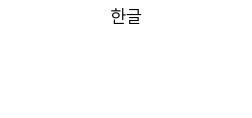

In [13]:
import platform
from matplotlib import font_manager
import matplotlib.pyplot as plt

system = platform.system()
if system == 'Windows':
    # Windows는 맑은 고딕이 기본 내장되어 있어 설치 없이 바로 사용 가능
    plt.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    # macOS 기본 내장 한글 폰트
    plt.rc('font', family='AppleGothic')
else:
    # Colab 등 Linux: 위 셀에서 설치한 나눔고딕을 등록
    font_dir = '/usr/share/fonts/truetype/nanum'
    font_files = font_manager.findSystemFonts(fontpaths=font_dir)
    for fpath in font_files:
        font_manager.fontManager.addfont(fpath)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# 설정한 폰트가 실제로 잡혔는지 확인
print('적용된 폰트:', plt.rcParams['font.family'])
plt.figure(figsize=(3,1))
plt.title('한글')
plt.axis('off')
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import pandas as pd

In [15]:
ticker = '005930.KS'
start_date = '2018-01-01'
end_date = '2023-01-01'
stock_data = yf.download(ticker,
                         start=start_date,
                         end=end_date)

df = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']]
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2018-01-02,41451.048826,41467.183917,40966.996095,41160.617188,8474250
2018-01-03,42386.878145,42403.013234,41483.313175,41644.664062,10013500
2018-01-04,42048.032247,42096.437503,40854.035936,41209.007812,11695450
2018-01-05,41386.504303,42048.042969,41305.828856,42048.042969,9481150
2018-01-08,42273.933884,42370.744419,41547.854867,41967.367188,8383650


In [16]:
df = df.dropna()
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df), columns=df.columns, index=df.index)

In [17]:
def create_sequence(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data.iloc[i:(i + seq_length)].values
        y = data.iloc[i + seq_length]['Close']
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys).reshape(-1, 1)

seq_length = 20

X, y = create_sequence(df_scaled, seq_length)
print(X.shape, y.shape)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

(1210, 20, 5) (1210, 1)


In [18]:
class StockModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.2):
        super(StockModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:,-1,:]
        out = self.dropout(last_time_step)
        predictions = self.fc(out)
        return predictions

input_size = X_train.shape[2]
hidden_size = 64
num_layers = 2
model = StockModel(input_size, hidden_size, num_layers)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
batch_size = 32
train_losses = []
val_losses = []
best_val_loss = float('inf')

In [19]:
for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i:i + batch_size]
        batch_y = y_train[i:i + batch_size]

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm(model.parameters(), max_norm = 1.0)
        optimizer.step()
    model.eval()
    with torch.no_grad():
        train_preds = model(X_train)
        train_loss = criterion(train_preds, y_train).item()
        train_losses.append(train_loss)
        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val).item()
        val_losses.append(val_loss)
    print(epoch + 1, train_loss, val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_stock_model.pt')

model.load_state_dict(torch.load('best_stock_model.pt'))
model.eval()
with torch.no_grad():
    test_predictions = model(X_test)
test_dates = df.index[train_size + val_size + seq_length:]

def inverse_transform_close(data):
    dummy = np.zeros((len(data), 5))
    dummy[:,3] = data.flatten()
    return scaler.inverse_transform(dummy)[:,3]

y_test_orig = inverse_transform_close(y_test.numpy())
test_predictions_orig = inverse_transform_close(test_predictions.numpy())

mse = mean_squared_error(y_test_orig, test_predictions_orig)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_orig, test_predictions_orig)
r2 = r2_score(y_test_orig, test_predictions_orig)

print(mse)
print(rmse)
print(mae)
print(r2)

C:\Users\KDS23\AppData\Local\Temp\ipykernel_12408\3788705584.py:11: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  nn.utils.clip_grad_norm(model.parameters(), max_norm = 1.0)


1 0.17137418687343597 0.03623838722705841
2 0.025558428838849068 0.08413567394018173
3 0.0026940028183162212 0.007308036554604769
4 0.01026145275682211 0.020414501428604126
5 0.015761593356728554 0.014958477579057217
6 0.0014371884753927588 0.002123002428561449
7 0.0016750466311350465 0.0022077802568674088
8 0.0019880987238138914 0.004155174363404512
9 0.004594595171511173 0.00739023182541132
10 0.0011015509953722358 0.0012209734413772821
11 0.0029388361144810915 0.005037203896790743
12 0.0011025837156921625 0.0035645628813654184
13 0.0011598705314099789 0.001045956276357174
14 0.001442487700842321 0.003223725827410817
15 0.0009922838071361184 0.0009242123342119157
16 0.0022754601668566465 0.0033187572844326496
17 0.0007799448794685304 0.0010257797548547387
18 0.0030326303094625473 0.004698858596384525
19 0.005154706072062254 0.007160339504480362
20 0.011165539734065533 0.016979563981294632
21 0.0009108777157962322 0.0016369438963010907
22 0.0030164862982928753 0.006346881855279207
23 

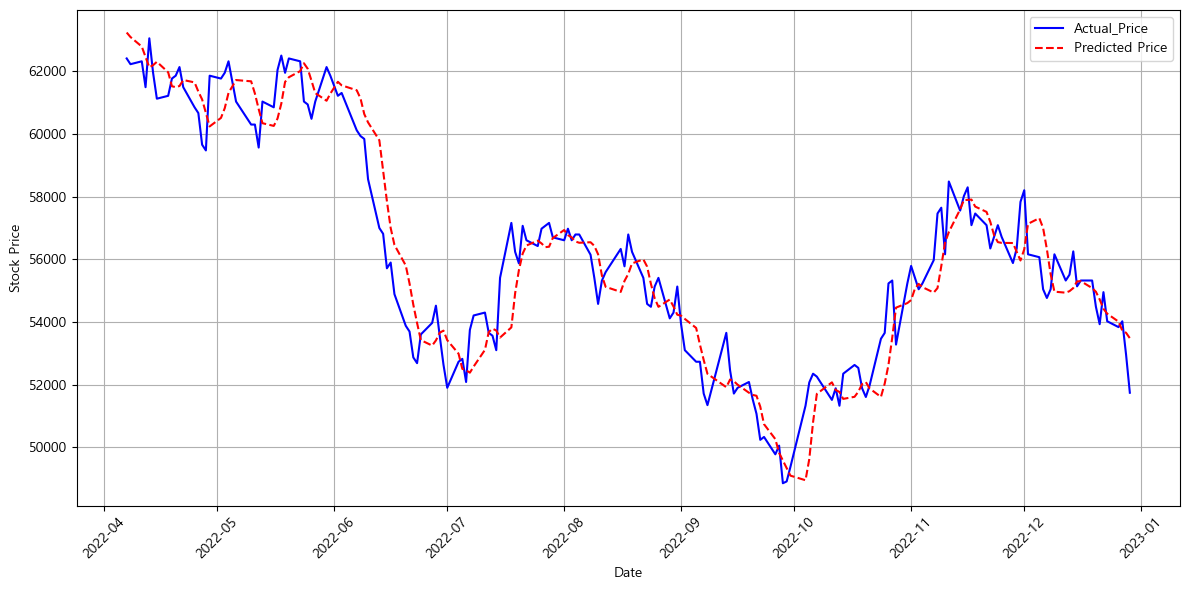

In [20]:
plt.figure(figsize=(12,6))
plt.plot(test_dates, y_test_orig, 'b-', label='Actual_Price')
plt.plot(test_dates, test_predictions_orig, 'r--', label='Predicted Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
from torch.nn.utils.rnn import pad_sequence

def build_vocab(tokenized_texts, min_freq=1):
    word_counts = {}
    for text in tokenized_texts:
        for token in text:
            word_counts[token] = word_counts.get(token, 0) + 1
        vocab = {'<pad>': 0,
                 '<unk>': 1}
        idx = 2
        for word, count in word_counts.items():
            if count >= min_freq:
                vocab[word] = idx
                idx += 1
        return vocab

def text_to_indices(tokenized_text, vocab):
    return [vocab.get(token, vocab['<unk>']) for token in tokenized_text]

sequences = [torch.tensor([1,2,3]), torch.tensor([4,5]), torch.tensor([6,7,8,9])]
padded_seq = pad_sequence(sequences, batch_first=True)
print(padded_seq)

mask = (padded_seq != 0).float()

tensor([[1, 2, 3, 0],
        [4, 5, 0, 0],
        [6, 7, 8, 9]])


In [22]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim,
                 hidden_dim, output_dim, n_layers=1,
                 bidirectional=False, dropout=0.5, pad_idx=0):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size,
                                      embedding_dim,
                                      padding_idx=pad_idx)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim,
                            output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text, text_length):
        embedded = self.embedding(text)
        packed_embedded = nn.utils.rnn.pack_sequence(embedded,
                                                     text_length.cpu(),
                                                     batch_first=True,
                                                     enforce_sorted=False)
        packed_output, (hidden, _) = self.rnn(packed_embedded)

        if self.rnn.bidirectional:
            hidden = self.dropout(torch.cat((hidden[-2,:,:],
                                             hidden[-1,:,:]),
                                             dim=1))
        else:
            hidden = self.dropout(hidden[-1,:,:])
        return self.fc(hidden)

In [23]:
# 09/10
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

torch.manual_seed(42)
np.random.seed(42)

def simple_tokenize(text):
    return text.split()
# 샘플 데이터 생성
sample_texts = [
    ("This movie is truly a masterpiece with excellent directing and standout "
     "acting"),
    ("The acting was good but the story was too predictable and "
     "disappointing"),
    "This is the worst trash movie I've ever seen",
    ("The actors' performances were lacking but the visuals were beautiful"),
    ("The story is simple but the film had many moving scenes"),
    ("The boring progression and sloppy script made me feel like I wasted my "
     "time"),
    ("This is a much more polished work than the director's previous films"),
    ("An overrated movie that wasn't very entertaining"),
    ("The most impressive film I've seen this year, I definitely recommend it"),
    ("The directing was good but the actors' awkward performances made it "
     "hard to get immersed")
]
sample_labels = [1, 0, 0, 0, 1, 0, 1, 0, 1, 0] # 1: 긍정, 0: 부정

def build_vocab(tokenized_texts, min_freq=1):
    word_counts = {}
    for text in tokenized_texts:
        for token in text:
            word_counts[token] = word_counts.get(token, 0) + 1
    vocab = {'<pad>': 0,
                '<unk>': 1}
    idx = 2
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

def text_to_indices(tokenized_text, vocab):
    return [vocab.get(token, vocab['<unk>']) for token in tokenized_text]

In [24]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim, attention_dim = 128):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Linear(hidden_dim, attention_dim)
        self.context = nn.Linear(attention_dim, 1, bias=False)
    def forward(self, x, mask=None):
        attention = torch.tanh(self.attention(x))
        attention = self.context(attention).squeeze(2)
        if mask is not None:
            attention = attention.masked_fill(mask == 0, -1e10)
        attention_weights = torch.softmax(attention, dim=1)
        weighted_output = torch.bmm(attention_weights.unsqueeze(1), x).squeeze(1)
        return weighted_output, attention_weights

class AttentionRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 attention_dim=128, n_layers=1, bidirectional=True,
                 dropout=0.5, pad_idx=0):
        super(AttentionRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim,
                                      padding_idx=pad_idx)
        self.rnn = nn.LSTM(embedding_dim, hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)
        self.attention = AttentionLayer(hidden_dim * 2 if bidirectional else hidden_dim,
                                        attention_dim)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim,
                            output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text, text_lengths):
        embedded = self.embedding(text)
        packed_embedded = pack_padded_sequence(embedded,
                                               text_lengths.cpu(),
                                               batch_first=True,
                                               enforce_sorted=False)
        packed_output, _ = self.rnn(packed_embedded)
        output, _ = pad_packed_sequence(packed_output,
                                        batch_first=True)
        mask = (text !=0)
        weighted_output, attention_weights = self.attention(output, mask)
        weighted_output = self.dropout(weighted_output)
        return self.fc(weighted_output), attention_weights

In [25]:
tokenized_texts = [simple_tokenize(text) for text in sample_texts]
vocab = build_vocab(tokenized_texts)
print(len(vocab))

vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 128
output_dim = 1
attention_dim = 64
model = AttentionRNN(vocab_size, embedding_dim,
                     hidden_dim, output_dim,
                     attention_dim)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 100
batch_size = 2

78


In [26]:
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for i in range(0, len(sample_texts), batch_size):
        batch_indices = range(i, min(i + batch_size, len(sample_texts)))
        batch_texts = [tokenized_texts[idx] for idx in batch_indices]
        batch_labels = torch.tensor([sample_labels[idx] for idx in batch_indices],
                                    dtype = torch.float)
        batch_lengths = torch.tensor([len(text) for text in batch_texts])
        batch_indices = [text_to_indices(text, vocab) for text in batch_texts]
        batch_texts_tensor = pad_sequence([torch.tensor(indices) for indices in batch_indices],
                                           batch_first=True,
                                           padding_value=0)
        predictions, _ = model(batch_texts_tensor, batch_lengths)
        predictions = predictions.squeeze(1)

        loss = criterion(predictions, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(epoch +1, epoch_loss)
model.eval()

10 0.1974027343094349
20 0.009266334120184183
30 0.0066056117648258805
40 0.0039015829970594496
50 0.0018082040041917935
60 0.0020901729876641184
70 0.001353740255581215
80 0.0011659391748253256
90 0.001126707371440716
100 0.001231396039656829


AttentionRNN(
  (embedding): Embedding(78, 100, padding_idx=0)
  (rnn): LSTM(100, 128, batch_first=True, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=256, out_features=64, bias=True)
    (context): Linear(in_features=64, out_features=1, bias=False)
  )
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Text: This movie is truly a masterpiece with excellent directing and standout acting
Actual sentiment: Positive
Predicted sentiment: Positive (Confidence: 0.9998)
Attention weights: [1.8732379e-04 3.5898405e-04 2.2820089e-04 7.0111302e-04 8.8966694e-03
 6.1086912e-02 9.5941491e-02 1.8876682e-01 1.5393759e-01 1.6565476e-01
 1.8736859e-01 1.3687159e-01]
--------------------------------------------------------------------------------
Text: The acting was good but the story was too predictable and disappointing
Actual sentiment: Negative
Predicted sentiment: Negative (Confidence: 0.0001)
Attention weights: [0.03519879 0.06890187 0.15438952 0.14343806 0.17676242 0.10244358
 0.13930011 0.11314856 0.05700872 0.00786009 0.00066065 0.00088759]
--------------------------------------------------------------------------------
Text: This is the worst trash movie I've ever seen
Actual sentiment: Negative
Predicted sentiment: Negative (Confidence: 0.0002)
Attention weights: [0.1300198  0.09879968 0.2

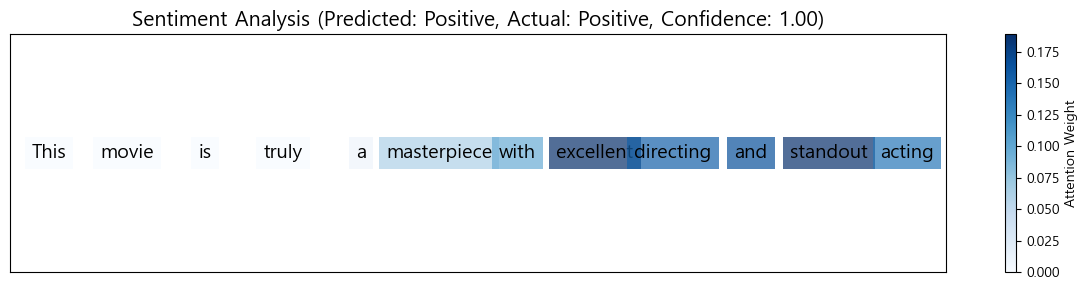

Figure 6-5 has been saved as 'attention_figure6-5.png'.


In [27]:
def plot_attention(text, attention_weights, prediction, actual):
    fig, ax = plt.subplots(figsize=(12, 3))
    norm = mcolors.Normalize(vmin=0, vmax=max(attention_weights))
    for i, (word, weight) in enumerate(zip(text, attention_weights)):
        color_intensity = plt.cm.Blues(norm(weight))
        ax.text(i, 0.5, word, ha='center', va='center', fontsize=14,
                bbox= dict(facecolor= color_intensity, alpha= 0.7,
                           edgecolor='none', pad=5))
    ax.set_xlim(-0.5, len(text) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_title((f'Sentiment Analysis (Predicted: {"Positive" if prediction > 0.5 else "Negative"}, '
                  f'Actual: {"Positive" if actual == 1 else "Negative"}, '
                  f'Confidence: {prediction:.2f})'), fontsize=15)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Attention Weight')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    return fig
# Predictions and attention visualization for all samples
for i, (text, label) in enumerate(zip(tokenized_texts, sample_labels)):
    indices = text_to_indices(text, vocab)
    text_tensor = torch.tensor(indices).unsqueeze(0)
    text_length = torch.tensor([len(indices)])
    with torch.no_grad():
        prediction, attention = model(text_tensor, text_length)
        prediction = torch.sigmoid(prediction).item()
        attention = attention.squeeze().numpy()
    print(f"Text: {' '.join(text)}")
    print(f"Actual sentiment: {'Positive' if label == 1 else 'Negative'}")
    print(f"Predicted sentiment: {'Positive' if prediction > 0.5 else 'Negative'} (Confidence: {prediction:.4f})")
    print(f"Attention weights: {attention}")
    print("-" * 80)
    if i == 0:
        fig = plot_attention(text, attention, prediction, label)
        plt.savefig('attention_figure6-5.png', dpi=300, bbox_inches='tight')
        plt.close()
# Detailed visualization for a specific sentence
test_idx = 0
test_text = tokenized_texts[test_idx]
test_label = sample_labels[test_idx]
test_indices = text_to_indices(test_text, vocab)
test_tensor = torch.tensor(test_indices).unsqueeze(0)
test_length = torch.tensor([len(test_indices)])
with torch.no_grad():
    prediction, attention_weights = model(test_tensor, test_length)
    prediction = torch.sigmoid(prediction).item()
    attention_weights = attention_weights.squeeze().numpy()
fig = plot_attention(test_text, attention_weights, prediction, test_label)
plt.savefig('attention_figure6-5.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 6-5 has been saved as 'attention_figure6-5.png'.")

In [28]:
hyperparameters = {'hidden_size': [64, 128, 256, 512],
                   'num_layers': [1, 2, 3, 4],
                   'dropout': [0.0, 0.1, 0.2, 0.3, 0.5],
                   'bidirectional': [True, False],
                   'learning_rate': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
                   'batch_size': [16, 32, 64, 128],
                   'sequence_lenght': [50, 100, 200, 500],
                   'weight_decay': [0, 1e-5, 1e-4, 1e-3],
                   'grad_clip': [0, 0.5, 1.0, 5.0],
                   'optimizer': ['adam', 'sgd', 'rmsprop'],
                   'scheduler': ['cosine', 'step', 'plateau']}

In [29]:
import itertools
from sklearn.model_selection import ParameterGrid

class RNNHyperparameterTuner:
    def __init__(self, model_class, train_loader, val_loader, device):
        self.model_class = model_class
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.results = []

    def grid_search(self, param_grid, max_trials=50):
        param_combinations = list(ParameterGrid(param_grid))
        if len(param_combinations) > max_trials:
            import random
            param_combinations = random.sample(param_combinations, max_trials)

        best_score = float('inf')
        best_params = None

        for i, params in enumerate(param_combinations):
            print(i + 1, len(param_combinations), params)
            try:
                import time
                time.sleep(0.1)
                score = -sum(params.values())
                self.results.append({'params': params,
                                     'score': score})
                if score > best_score:
                    best_score = score
                    best_params = params
                    print(f'New score {best_score}')
            except Exception as e:
                print(f'Trial Fail {e}')
        return best_params, best_score

    def _train_and_evaluate(self, params):
        raise NotImplemented

In [30]:
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical

class BayesianOptimizer:
    def __init__(self, model_class, train_loader, val_loader):
        self.model_class = model_class
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.space = [Integer(64, 512, name='hidden_size'),
                      Integer(1, 4, name='num_layers'),
                      Real(0.0, 0.5, name='dropout'),
                      Real(1e-5, 1e-2 , prior='log-unifrom', name='learning_rate'),
                      Categorical([16, 32, 64, 128], name='batch_size'),
                      Real(0, 5.0, name='grad_clip')]

    def objective(self, params):
        hidden_size, num_layers, dropout, lr, batch_size, grad_clip = params
        model_params = {'hidden_size': hidden_size,
                        'num_layers': num_layers,
                        'dropout': dropout}
        train_params = {'learning_rate': lr,
                        'batch_size': batch_size,
                        'grad_clip': grad_clip}
        try:
            import time
            time.sleep(0.1)
            score = -(hidden_size + num_layers * 10 + dropout * 50 + lr * 10000 + batch_size / 10 + grad_clip * 5)
            return -score
        except Exception as e:
            print(f'Evaluation Fail {e}')
            return 1.0

    def _train_and_evaluate(self, model_params, train_params):
        raise NotImplementedError('구현해')

    def optimize(self, n_calls=50):
        res = gp_minimize(self.objective, self.space, n_calls=n_calls, random_state=42)
        best_params_list = res.x
        best_score = -res.fun
        param_names = [s.name for s in self.space]
        best_params = dict(zip(param_names, best_params_list))

        print(best_score)
        for name, value in best_params.item():
            print(name, value)
        return best_params, best_score

In [31]:
class AdaptiveLearningRateScheduler:
    def __init__(self, optimizer, mode='min', factor=0.5,
                 patience=5, min_lr = 1e-6, warmup_epochs=5):
        self.optimizer = optimizer
        self.mode = mode
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.warmup_epochs = warmup_epochs
        self.best_score = float('inf') if mode == 'min' else float('-inf')
        self.patience_counter = 0
        self.current_epoch = 0
    def step(self, current_score):
        self.current_epoch += 1
        if self.current_epoch <= self.warmup_epochs:
            lr_scale = self.current_epoch / self.warmup_epochs
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = param_group['initial_lr'] * lr_scale
                return
            is_improvement = ((self.mode == 'min' and current_score < self.best_score) or
                              (self.mode == 'max' and current_score > self.best_score))
            
            if is_improvement:
                self.best_score = current_score
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.patience:
                    self._reduce_lr()
                    self.patience_counter = 0

    def _reduce_lr(self):
        for param_group in self.optimizer.param_groups:
            old_lr = param_group['lr']
            new_lr = max(old_lr * self.factor, self.min_lr)
            param_group['lr'] = new_lr
            print(old_lr, new_lr)

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.family'] = 'Malgun Gothic'

np.random.seed(42)
torch.manual_seed(42)

In [33]:
def generate_time_series(n_samples=1000,
                         anomaly_positions=[200, 400, 600, 800]):
    t = np.linspace(0, 10, n_samples)
    series = 0.8 * np.sin(t) + 0.2 * np.sin(5 * t) + 0.1 * np.random.randn(n_samples)
    trend = 0.005 * np.arange(n_samples)
    series += trend

    for pos in anomaly_positions:
        if pos < n_samples:
            series[pos] += 1.5 * np.random.rand() + 0.5
            if np.random.rand() > 0.5 and pos + 1 < n_samples:
                series[pos + 1] -= 1.2 * np.random.rand() + 0.3
    return series

In [34]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, sequence_length):
        super(LSTMAutoencoder, self).__init__()
        self.hidden_size = hidden_size
        self.sequence_length = sequence_length
        self.encoder = nn.LSTM(input_size=input_size,
                               hidden_size=hidden_size,
                               num_layers=1,
                               batch_first=True)
        self.decoder = nn.LSTM(input_size=hidden_size,
                               hidden_size=input_size,
                               num_layers=1,
                               batch_first=True)
        self.fc = nn.Linear(input_size, input_size)
    def forward(self, x):
        _, (hidden, cell) = self.encoder(x)
        decoder_input = hidden.permute(1, 0, 2).repeat(1, self.sequence_length, 1)
        output, _ = self.decoder(decoder_input)
        reconstructed = self.fc(output)
        return reconstructed
def create_windows(data, window_size):
    X = []
    for i in range(len(data) - window_size + 1):
        X.append(data[i:i + window_size])
    return np.array(X)
def detect_anomalies(model, data, window_size, threshold):
    model.eval()
    anomalies = []
    with torch.no_grad():
        for i in range(len(data) - window_size + 1):
            sequence = data[i:i + window_size]
            sequence_tensor = torch.FloatTensor(sequence).unsqueeze(0).unsqueeze(2)
            reconstructed = model(sequence_tensor)
            error = torch.mean(torch.abs(reconstructed - sequence_tensor)).item()
            if error > threshold:
                anomalies.append((i + window_size -1, error))
    return anomalies
def set_threshold(errors, z_score=3.0):
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    return mean_error + z_score * std_error
def visualize_anomalies(data, anomalies, window_size=None, title=('비정상감지')):
    plt.figure(figsize=(15,7))
    plt.plot(data, label='Orignal Data', color='blue', alpha=0.7)
    if anomalies:
        anomaly_indices, anomaly_scores = zip(*anomalies)
        plt.scatter(anomaly_indices, [data[i] for i in anomaly_indices],
                    color='red', label='Anomalies', s=100)
        top_anomalies = sorted(anomalies, key=lambda x: x[1], reverse=True)[:5]
        for idx, score in top_anomalies:
            plt.annotate(f'{score:3f}', (idx, data[idx]),
                            xytext=(10, 10),
                            textcoords = 'offset points',
                            fontsize=10,
                            color='darkred')
    plt.title(title, fontsize=6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    return plt

10 0.0019429520154172493
20 0.0018756605507226833
30 0.0018820202881878547
40 0.001883615032844739
50 0.0018842322035112573
60 0.0018844546229938362
70 0.001884463081795202
80 0.0018851413893742177
90 0.0018948115395129516
100 0.0018959179113331374
110 0.0013889169495383792
120 0.00022945940566570077
130 0.00011918541399650959
140 9.993579039643504e-05
150 6.151547934100502e-05
160 5.204837117059333e-05
170 4.7764433321194626e-05
180 4.500779572486969e-05
190 4.206391603939395e-05
200 3.8771678722785384e-05
0.04612532122796305
6


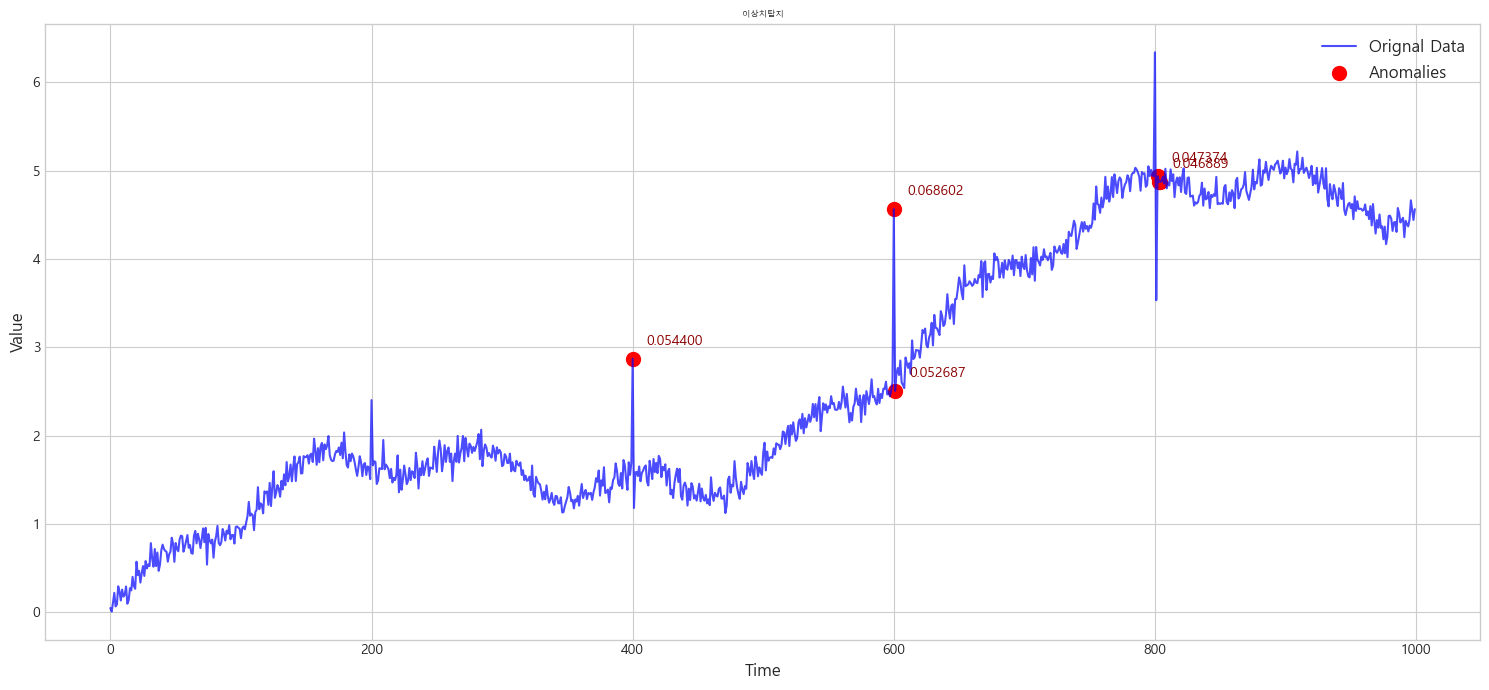

In [35]:
data = generate_time_series(n_samples=1000)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1)).flatten()
window_size = 20
X = create_windows(data_scaled, window_size)
X_tensor = torch.FloatTensor(X).unsqueeze(2)
input_size = 1
hidden_size = 32
sequence_length = window_size

model = LSTMAutoencoder(input_size, hidden_size, sequence_length)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
n_epochs = 200
batch_size = 32

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for i in range(0, len(X_tensor), batch_size):
        batch = X_tensor[i:i + batch_size]
        reconstructed = model(batch)
        loss = criterion(reconstructed, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(epoch + 1, train_loss/len(X_tensor))

model.eval()
errors = []
with torch.no_grad():
    for i in range(len(X_tensor)):
        seq = X_tensor[i:i + 1]
        reconstructed = model(seq)
        error = torch.mean(torch.abs(reconstructed - seq)).item()
        errors.append(error)

threshold = set_threshold(errors, z_score=3.0)
print(threshold)

anomalies = detect_anomalies(model, data_scaled, window_size, threshold)
print(len(anomalies))

data_orig = scaler.inverse_transform(data_scaled.reshape(-1,1)).flatten()

plt = visualize_anomalies(data_orig,
                          anomalies,
                          window_size,
                          title='이상치탐지')
plt.show()